### Цель задачи:
Провести анализ данных в датасете `data.tsv` и проверить гипотезу, что интересы людей, пользующихся поиском по картинкам у пользователей мобильных устройств и компьютера отличаются.

### Этапы выполнения задачи
1. Загрузить датасет data.tsv и предобработать данные
2. Указать даты диапазона представленного для анализа датасета
3. Рассчитать кол-во запросов с текстом "ютуб"  в каждой платформе (desktop, touch)
4. Вывести топ 10 самых частотных запросов в каждой платформе (desktop, touch), выявить отличия
5. Посмотреть, чем отличается трафик запросов в течении дня и объяснить отличие
6. Выделить тематики запросов, контрастные для мобильных и компьютеров - темы, доля которых отличаются на разных платформах

In [1]:
#Загружаем необходимые для анализа библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Загружаем датасет
df = pd.read_csv('data.tsv', sep='\t', header=None)

In [4]:
#Выведем первые пять строк для проверки
df.head()

,0,1,2
0,порно фото,1631786697,touch
1,малевич картины,1631806465,desktop
2,Секс,1631781583,touch
3,с днём рождения лена,1631771563,touch
4,зверополис порно,1631787599,touch


In [5]:
#Приведем столбец 2 к формату даты и времени
df[1] = pd.to_datetime(df[1], unit='s')

In [6]:
#Переименуем столбцы и сохраним все в датасет data
data = df.rename(columns={0:'query', 1:'date', 2:'platform'})

In [7]:
#Выведем информацю о датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1203824 entries, 0 to 1203823
Data columns (total 3 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   query     1203824 non-null  object        
 1   date      1203824 non-null  datetime64[ns]
 2   platform  1203824 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 27.6+ MB


В датасете 1 203 824 строк, 3 столбца,  пропусков не обнаружено, данных в верных форматах (строковые значение и дата и время).

In [8]:
#Приведем все запросы к нижнему регистру для исключения дубликатов запросов
data['query'] = data['query'].astype(str).str.lower()

In [9]:
#Посчитаем количество дубликатов
print("Количество дубликатов:", data.duplicated().sum())

Количество дубликатов: 565


In [10]:
#Выведем пример дубликатов
(data[data.duplicated()]).sort_values(by = ['query', 'date']).head(6)

,query,date,platform
781297,1 сентября,2021-09-01 03:20:58,touch
505365,1 сентября,2021-09-01 04:04:28,touch
1113495,1 сентября,2021-09-01 04:12:14,touch
825101,1 сентября,2021-09-01 05:26:00,touch
876164,1 сентября,2021-09-01 05:50:14,touch
869862,1 сентября,2021-09-01 07:00:43,touch


Нет необходимости удалять дубликаты, так как они таковыми не являются. Одинаковые запросы могут быть сделаны пользователями в разное время.

In [11]:
#Рассчитаем диапазон дат анализа
start_date = data['date'].min()
end_date = data['date'].max()
print(f'Диапазон дат для анализа: c {start_date} до {end_date}')

Диапазон дат для анализа: c 2021-08-31 21:00:00 до 2021-09-21 20:59:59


In [12]:
#Посчитаем колчиество запросов со словом ютуб в разрезе платформ
youtube_querys = data[data['query'].str.contains('ютуб', case=False)].groupby('platform').size()
print("Количество запросов с 'ютуб' по платформам:")
print(youtube_querys)

Количество запросов с 'ютуб' по платформам:
platform
desktop    806
touch      732
dtype: int64


In [13]:
#Выведем топ 10 запросов на компьютере
top_10_desktop = data[data['platform'] == 'desktop'].groupby('platform')['query'].value_counts().head(10)
top_10_desktop

platform  query                          
desktop   календарь 2021                     2810
          таблица менделеева                 2659
          картинки                           1720
          порно                              1408
          английский алфавит                 1352
          обои на рабочий стол               1143
          одноклассники (социальная сеть)    1116
          секс                                947
          алфавит                             923
          таблица квадратов                   883
Name: query, dtype: int64

In [14]:
#Выведем топ 10 запросов на мобильном телефоне
top_10_touch = data[data['platform'] == 'touch'].groupby('platform')['query'].value_counts().head(10)
top_10_touch

platform  query                  
touch     порно                      10076
          секс                        8262
          с днём рождения женщине     4924
          хентай                      4194
          с днём рождения             4123
          с днём рождения мужчине     3669
          с днем рождения             3315
          xxx                         3249
          xnxx                        2767
          доброе утро                 2342
Name: query, dtype: int64

In [15]:
#Для анализа трафика запросов по времени суток добавим столбец с часом дня
data['hour'] = data['date'].dt.hour

In [16]:
#Рассчитаем траффик по платформам и времени суток
day_traffic = data.groupby(['platform', 'hour']).size().reset_index(name='request_count')

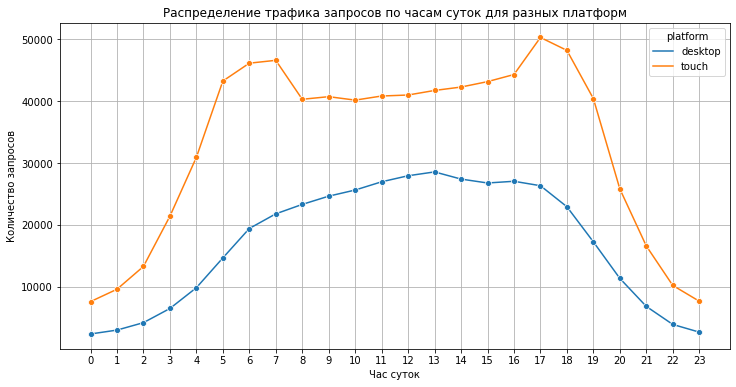

In [17]:
#Построим график распределения трафика
plt.figure(figsize=(12, 6))
sns.lineplot(data=day_traffic, x='hour', y='request_count', hue='platform', marker='o')
plt.title('Распределение трафика запросов по часам суток для разных платформ')
plt.xlabel('Час суток')
plt.ylabel('Количество запросов')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [32]:
# Посчитаем долю каждого запроса на платформах
topic_platform = data.groupby(['query', 'platform']).size().reset_index(name='count')
topic_platform.head()

,query,platform,count
0,+18,desktop,11
1,+18,touch,34
2,+18 video,desktop,2
3,+18 video,touch,24
4,002,desktop,4


In [40]:
#Создадим сводную табблицу по полученным данным
pivot = topic_platform.pivot(index = 'query', columns = 'platform', values = 'count')
#Посчитаем общее количество запросов
pivot['total'] = pivot['desktop'] + pivot['touch']
#Посчитаем долю запросов на компьютере
pivot['desktop_share'] = (pivot['desktop']/pivot['total'] * 100).round()
#Посчитаем долю запросов на мобильном телефоне
pivot['touch_share'] = (pivot['touch']/pivot['total'] * 100).round()
#Выведем первые пять строк сводной таблицы
pivot.head()

platform,desktop,touch,total,desktop_share,touch_share
query,,,,,
+18,11.0,34.0,45.0,24.0,76.0
+18 video,2.0,24.0,26.0,8.0,92.0
002,4.0,15.0,19.0,21.0,79.0
02 аниме,34.0,30.0,64.0,53.0,47.0
02 милый во франсе,7.0,23.0,30.0,23.0,77.0


In [44]:
#Топ запросов, которые в 99-100% случаев используются на компьютере
top_desktop = pivot.sort_values(by = 'desktop_share', ascending = False).head(10)
top_desktop

platform,desktop,touch,total,desktop_share,touch_share
query,,,,,
одноклассники (социальная сеть),1116.0,5.0,1121.0,100.0,0.0
портал государственных услуг российской федерации,369.0,1.0,370.0,100.0,0.0
обои на рабочий стол красивые большие на весь экран бесплатно,467.0,5.0,472.0,99.0,1.0
портал государственных услуг российской федерации личный кабинет,80.0,1.0,81.0,99.0,1.0
календарь на 2021-2022 учебный год для учителя скачать,259.0,3.0,262.0,99.0,1.0
gmail.com,90.0,1.0,91.0,99.0,1.0
google (компания),105.0,1.0,106.0,99.0,1.0
обои на пк,228.0,2.0,230.0,99.0,1.0
grand theft auto san andreas,80.0,1.0,81.0,99.0,1.0


In [45]:
#Топ запросов, которые в 99-100% случаев используются на мобильном телефоне
top_touch = pivot.sort_values(by = 'touch_share', ascending = False).head(10)
top_touch

platform,desktop,touch,total,desktop_share,touch_share
query,,,,,
colmek,1.0,261.0,262.0,0.0,100.0
bokep indo,1.0,242.0,243.0,0.0,100.0
с днём рождения доченьки,1.0,72.0,73.0,1.0,99.0
sex anime,1.0,74.0,75.0,1.0,99.0
поздравления с днём рождения женщине открытки,1.0,112.0,113.0,1.0,99.0
сын президента россии,1.0,118.0,119.0,1.0,99.0
с днём рождения дочки,1.0,67.0,68.0,1.0,99.0
bokep,18.0,1508.0,1526.0,1.0,99.0
с днём рождения подруге прикольные,1.0,70.0,71.0,1.0,99.0


Проведя анализ предоставленных данных запросов пользователей, можно сказать, что существенно контрастируют тематики запросов на разных устройствах:

- ПК (desktop) — домен официальных, рабочих, обучающих, информационных запросов и крупных веб-ресурсов.

- Мобильные (touch) — домен личных коммуникаций, развлекательного и взрослого контента, поздравлений и т.д.


Это отражает разное использование платформ: ПК часто задействуются для более глобальных и рабочих задач, мобильные — для повседневного, быстрого и личного доступа к контенту и общению.

1. В датасете представлен анализ в диапазоне c 2021-08-31 21:00:00 до 2021-09-21 20:59:59

2. Запрос `ютуб` чаще используется на компьютере , чем на мобильном телефоне (806 запросов на компьютере против 732 на мобильном телефоне.) Разница небольшая, но это может быть связано с тем, что на мобильных телефонах чаще всего приложение YouTube предустановлено, поэтому поиск в сети для перехода в приложение не нужен.

3. Анализируя запросы, сделанные с компьютера (desktop) и с мобильного (touch), можно выделить следующие ключевые отличия.

- на компьютерах лидируют более общие и информационные темы: "календарь 2021", "таблица менделеева", "картинки", "английский алфавит", "обои на рабочий стол", "одноклассники (соцсеть)", "таблица квадратов". Это говорит о том, что пользователи ПК чаще используют поиск для учебы, работы, познавательных целей и медиа-контента.

- на мобильных устройствах гораздо выше доля запросов с ярко выраженной личной и развлекательной тематикой: "порно", "секс", "с днём рождения женщине/мужчине", "хентай", "xxx", "xnxx", "доброе утро". Мобильный поиск явно больше ориентирован на развлечение и личные коммуникации, поздравления и мультимедийный контент.

- на компьютере значительно меньше запросов с сексуальным контентом (например, "порно" - 1408), тогда как на мобильных таких запросов много в разы ("порно" - 10076).

- пользователи мобильных устройств активно ищут поздравления и короткие тематические фразы ("с днём рождения", "доброе утро"), что скорее связано с мобильным образом жизни и удобством отправки сообщений.

Пользователи ПК используют поиск в большей степени для учебы, работы и получения справочной информации, тогда как посетители с мобильных устройств ориентированы на развлечение, личное общение и быстрый доступ к медиа и поздравлениям. Это отражает разное поведение и потребности пользователей в зависимости от устройства.

4. На мобильных устройствах (touch) пиковое количество запросов приходится на раннее утро (с 5 до 8 часов) и на конец рабочего дня (16–18 часов). Мобильный трафик высок с самого начала дня: резкий рост после 4 утра, максимальное значение с 5 до 8 часов, затем довольно стабильный уровень с небольшим вечерним всплеском и сокращением числа запросов после 20 часов.

На компьютерах (desktop) трафик начинает заметно расти с 5–6 часов утра, достигая плавного пика к 13–16 часам, а затем медленно снижается к вечеру и ночи.

Причины могут быть следующие:
- мобильные устройства используются для поиска с самого утра и до позднего вечера — во время утреннего пробуждения, перед выходом на работу или школу, и после рабочего дня, когда люди чаще используют смартфоны для личных целей и общения.

- компьютеры активно применяются в рабочее время, когда основной объем поиска связан с выполнением рабочих, учебных и деловых задач.

Мобильный поиск доминирует в утренние и вечерние часы, отражая гибкость и постоянную доступность смартфонов, тогда как десктоп используется преимущественно днем, совпадая с рабочей и учебной активностью. Это говорит о разном сценарии использования устройств для поиска информации в зависимости от времени суток и потребностей пользователей

5. Запросы, связанные с официальными сервисами и рабочими/учебными тематиками, такими как "одноклассники (социальная сеть)", "портал государственных услуг Российской Федерации", "календарь на 2021-2022 учебный год", "gmail.com", "google (компания)", а также компьютерные игры (например, "grand theft auto") практически полностью приходят с платформ desktop. Их доля на десктопе близка к 100%, а на мобильных — близка к 0%. Это свидетельствует о том, что такие информационные и функциональные запросы преимущественно делаются с компьютеров.

В то же время развлекательные, персональные и взрослые запросы, такие как "bokep indo", "с днём рождения доченьки", "sex anime", "поздравления с днём рождения женщине открытки" и подобные, почти полностью приходят с мобильных устройств с долей порядка 99-100% на mobile и близкой к нулю на desktop. Это означает, что мобильный поиск более ориентирован на развлекательные, эмоциональные и личные темы.